# Build dataset

Turns the raw LBM simulation bundle (`urban_flow_dataset_5225.npz`) into the
processed, per-case dataset that every later notebook consumes:

- **Raw fields** — height map, normalized mid-plane velocity, footprint and fluid masks
- **Building tokens** — `[x_center, y_center, l_x, l_y, h]`, normalized to `[0, 1]`
- **Morphology descriptors** — canonical 8-vector + alignedness family, per case
- **Splits** — 70 / 15 / 15 by full urban layout (no grid-point leakage)

All computation lives in `urbanformer.morphology` and `urbanformer.data`; this
notebook is orchestration and visualization only.

# Imports & Configuration

In [ ]:
import os
import json
import random
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# All morphology and data helpers live in the installed package now.
from urbanformer import morphology, data
from urbanformer.morphology import SOLID_CODE, DX, MORPHOLOGY_KEYS, ALIGNEDNESS_KEYS

In [ ]:
# ---- configuration -------------------------------------------------------
RAW_PATH   = '/home/las/Urban-Flow-Transformer/data/LBMpy_raw_dataset/urban_flow_dataset_5225.npz'
OUT_DIR    = '/home/las/Urban-Flow-Transformer/data/processed'
SPLITS_DIR = os.path.join(OUT_DIR, '..', 'splits')

# SOLID_CODE, DX, MORPHOLOGY_KEYS, ALIGNEDNESS_KEYS are imported from
# urbanformer.morphology so the notebook and the library can never disagree.

# ---- load the raw dataset once ------------------------------------------
raw  = np.load(RAW_PATH)              # note: 'raw', not 'data' (data is the module)
X    = raw['X']        # [N_cases, Ny, Nx]  height maps
y    = raw['y']        # [N_cases, Ny, Nx]  mid-plane streamwise velocity (raw)
geom = raw['geom']     # [N_cases, Ny, Nx]  cell-type codes (SOLID_CODE == building)
utau = raw['utau']     # [N_cases]          friction velocity, used as U_ref

N_CASES = len(X)
H_REF   = float(X.max())   # global height scale used to normalize token heights -> [0, 1]

print(f"cases={N_CASES}  map={X.shape[1:]}  H_REF={H_REF:.3f}")
print("geom codes in case 0:", np.unique(geom[0]))   # sanity-check that SOLID_CODE==8 is solid

# Helper functions

Morphology and data helpers now live in `urbanformer.morphology` and
`urbanformer.data`, each with its own regression tests. Only the plotting
helpers, which are notebook-local presentation code, remain defined here.

In [ ]:
def plot_simulation_u(ax, u_norm, solid_mask, title='', vmin=-1.0, vmax=2.5):
    """Plot the already-normalized mid-plane streamwise velocity ubar/utau.

    u_norm     : 2D array of ubar/utau (e.g. the saved U_mid.npy)
    solid_mask : boolean array, True where the mid-plane cuts a building
    The green mid-point of the colormap is pinned to u = 0, so `positions`
    stays monotonic only while vmin < 0 < vmax (default vmin=-1, vmax=2.5).
    """
    colors = [(0, 0, 0.5),      # dark blue
              (0, 0.8, 0.8),    # turquoise
              (0, 0.25, 0),     # dark green
              (0.7, 0.7, 0),    # yellow
              (0.4, 0, 0)]      # dark red
    positions = [0, 0.15, (0 - vmin) / (vmax - vmin), 0.55, 1]
    custom_cmap = mcolors.LinearSegmentedColormap.from_list(
        'custom', list(zip(positions, colors)))

    plot_data = u_norm.copy()
    plot_data[solid_mask] = 0
    cax = ax.imshow(plot_data, cmap=custom_cmap, interpolation='bicubic',
                    vmin=vmin, vmax=vmax, origin='upper')

    # black out the buildings cut by the mid-plane
    building_data = np.where(solid_mask, 0, np.nan)
    ax.imshow(building_data, cmap='gray', interpolation='nearest',
              origin='upper', zorder=2)

    ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_aspect('equal')
    ax.set_xticks(np.linspace(0, u_norm.shape[1] - 1, 6))
    ax.set_xticklabels(np.linspace(0, 1, 6).round(2))
    ax.set_yticks(np.linspace(0, u_norm.shape[0] - 1, 6))
    ax.set_yticklabels(np.linspace(1, 0, 6).round(2))
    ax.grid(False); ax.set_title(title)

    cbar = plt.colorbar(cax, ax=ax, orientation='horizontal',
                        fraction=0.046, pad=0.15, extend='both')
    cbar.set_label(r'$\overline{u}/u\tau$', fontsize=14)
    cbar.set_ticks(np.sort(np.append(np.linspace(vmin, vmax, 3), 0)))
    cbar.ax.tick_params(labelsize=12)
    return cax


def visualize_case(case_idx, vmin=-2.5, vmax=5.0, save_path=None):
    case_dir   = os.path.join(OUT_DIR, f'case_{case_idx:04d}')
    height_map = np.load(os.path.join(case_dir, 'height_map.npy'))
    u_mid      = np.load(os.path.join(case_dir, 'U_mid.npy'))
    fluid_mask = np.load(os.path.join(case_dir, 'fluid_mask_mid.npy'))
    solid_mask = fluid_mask == 0

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    im0 = axes[0].imshow(height_map, cmap='gray_r', origin='upper')
    plt.colorbar(im0, ax=axes[0], label='Normalized Height')
    axes[0].set_title(f'case_{case_idx:04d} \u2014 height map')

    plot_simulation_u(axes[1], u_mid, solid_mask, vmin=vmin, vmax=vmax,
                      title=f'case_{case_idx:04d} \u2014 mid-plane velocity')

    plt.tight_layout()

    if save_path:                                    # save BEFORE show
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        fig.savefig(save_path, dpi=150, bbox_inches='tight')

    plt.show()

    desc  = np.load(os.path.join(case_dir, 'global_descriptors.npy'))
    align = np.load(os.path.join(case_dir, 'alignedness_variants.npy'))
    with open(os.path.join(case_dir, 'metadata.json')) as f:
        meta = json.load(f)
    print(f"\n=== case_{case_idx:04d} morphology "
          f"(n_buildings={meta['n_buildings']}, U_ref={meta['U_ref']:.4f}) ===")
    print("  canonical descriptors:")
    for k, v in zip(MORPHOLOGY_KEYS, desc):
        print(f"    {k:>14} = {v:.4f}")
    print("  alignedness family:")
    for k, v in zip(ALIGNEDNESS_KEYS, align):
        print(f"    {k:>14} = {v:.4f}")

    return fig

#  Per-case folder creation

In [ ]:
# Saves the raw per-case fields that need no morphology: height map, normalized
# mid-plane velocity, building footprint mask, and the mid-plane fluid mask.
# Field names match the dict keys returned by data.case_fields.

for i in tqdm(range(N_CASES), desc="Folder creation", unit="case"):
    case_dir = os.path.join(OUT_DIR, f'case_{i:04d}')
    os.makedirs(case_dir, exist_ok=True)

    fields = data.case_fields(X[i], geom[i], y[i], utau[i])
    for name, arr in fields.items():
        np.save(os.path.join(case_dir, f'{name}.npy'), arr)

# quick sanity check
chk = np.load(os.path.join(OUT_DIR, 'case_0000', 'U_mid.npy'))
print("U_mid:", chk.shape, chk.min(), chk.max())

# Building token extraction

In [ ]:
# Token = [x_center, y_center, width(l_x), length(l_y), height] with every entry
# normalized to [0, 1] by data.build_tokens. Tokens are stored unshuffled; the
# train-time Dataset shuffles them for set-invariance.

for i in tqdm(range(N_CASES), desc="Building tokens", unit="case"):
    case_dir = os.path.join(OUT_DIR, f'case_{i:04d}')
    os.makedirs(case_dir, exist_ok=True)

    tokens = data.build_tokens(X[i], H_REF)
    np.save(os.path.join(case_dir, 'building_tokens.npy'), tokens)

# sanity check - all token entries should now lie in [0, 1]
tok = np.load(os.path.join(OUT_DIR, 'case_0000', 'building_tokens.npy'))
print("tokens:", tok.shape, "min=%.3f" % tok.min(), "max=%.3f" % tok.max())
assert tok.min() >= 0.0 and tok.max() <= 1.0 + 1e-6, "token normalization out of range"

# Global morphology computation

In [ ]:
# Per-building height statistics and densities (Alas et al.) plus the five
# alignedness descriptors (Lu et al. 2023), all from
# morphology.compute_global_descriptors. Writes the canonical 8-vector to
# global_descriptors.npy, the alignedness family to alignedness_variants.npy,
# and metadata.json - one per case.

for i in tqdm(range(N_CASES), desc="Global morphology", unit="case"):
    case_dir = os.path.join(OUT_DIR, f'case_{i:04d}')
    os.makedirs(case_dir, exist_ok=True)

    descriptors, alignedness, stats = morphology.compute_global_descriptors(X[i])

    np.save(os.path.join(case_dir, 'global_descriptors.npy'),   descriptors)
    np.save(os.path.join(case_dir, 'alignedness_variants.npy'), alignedness)

    metadata = {'case_idx': int(i), 'U_ref': float(utau[i]), **stats}
    with open(os.path.join(case_dir, 'metadata.json'), 'w') as f:
        json.dump(metadata, f, indent=2)

In [ ]:
# Dataset-wide descriptor summary
all_desc  = np.array([
    np.load(os.path.join(OUT_DIR, f'case_{i:04d}', 'global_descriptors.npy'))
    for i in range(N_CASES)
])
all_align = np.array([
    np.load(os.path.join(OUT_DIR, f'case_{i:04d}', 'alignedness_variants.npy'))
    for i in range(N_CASES)
])

def _summary(arr, keys, header):
    print(header)
    print(f"{'descriptor':>14}  {'min':>8}  {'mean':>8}  {'max':>8}  {'std':>8}")
    print("-" * 54)
    for j, k in enumerate(keys):
        col = arr[:, j]
        print(f"{k:>14}  {col.min():>8.4f}  {col.mean():>8.4f}  {col.max():>8.4f}  {col.std():>8.4f}")

_summary(all_desc,  MORPHOLOGY_KEYS,  "Canonical morphology descriptors (global_descriptors.npy)")
print()
_summary(all_align, ALIGNEDNESS_KEYS, "Alignedness family (alignedness_variants.npy)")

Canonical morphology descriptors (global_descriptors.npy)
    descriptor       min      mean       max       std
------------------------------------------------------
      lambda_p    0.2091    0.3912    0.5358    0.0459
      lambda_f    0.0154    0.0285    0.0448    0.0045
           h_m    0.4710    0.6329    0.7971    0.0668
         h_rms    0.0480    0.1084    0.1712    0.0178
        h_skew   -2.1092   -0.0519    1.5111    0.4613
        h_kurt   -1.6575   -0.5773    5.3057    0.6037
       gamma_m    0.2987    0.4162    0.5700    0.0488
         h_max    0.6087    0.8290    0.8696    0.0525

Alignedness family (alignedness_variants.npy)
    descriptor       min      mean       max       std
------------------------------------------------------
       gamma_m    0.2987    0.4162    0.5700    0.0488
  gamma_m_star   28.4479   53.4519   96.3143   10.4813
       gamma_s   14.7314   31.4334   60.4049    6.3063
       gamma_p    0.4944    0.7977    1.0000    0.1067
       gamma_c 

# Train / validation / test split

In [ ]:
# Split by full urban layout (no grid-point leakage): 70 / 15 / 15.
# data.make_splits reproduces this split exactly from the seed.

splits = data.make_splits(N_CASES, seed=42, fractions=(0.70, 0.15, 0.15))

os.makedirs(SPLITS_DIR, exist_ok=True)
for split_name, split_idx in splits.items():
    path = os.path.join(SPLITS_DIR, f'{split_name}_cases.txt')
    with open(path, 'w') as f:
        for idx in split_idx:
            f.write(f'case_{idx:04d}\n')
    print(f"{split_name:>5}: {len(split_idx)} cases  ->  {path}")

# sanity check - no overlap
assert set(splits['train']) & set(splits['val'])  == set()
assert set(splits['train']) & set(splits['test']) == set()
assert set(splits['val'])   & set(splits['test']) == set()
print("No overlap between splits.")

# Visualization

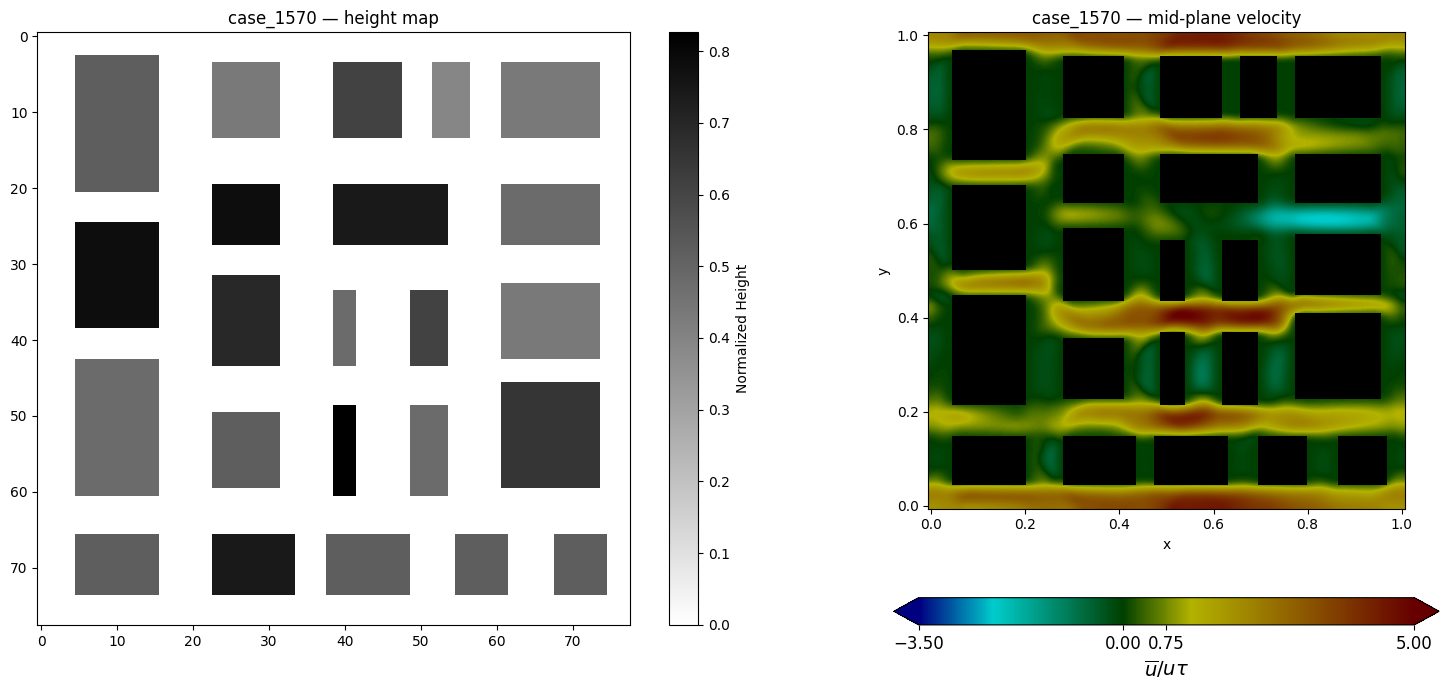


=== case_1570 morphology (n_buildings=23, U_ref=0.6427) ===
  canonical descriptors:
          lambda_p = 0.3728
          lambda_f = 0.0230
               h_m = 0.5728
             h_rms = 0.1273
            h_skew = 0.5969
            h_kurt = -0.9615
           gamma_m = 0.4346
             h_max = 0.8261
  alignedness family:
           gamma_m = 0.4346
      gamma_m_star = 59.0881
           gamma_s = 37.5357
           gamma_p = 0.8641
           gamma_c = 0.2807


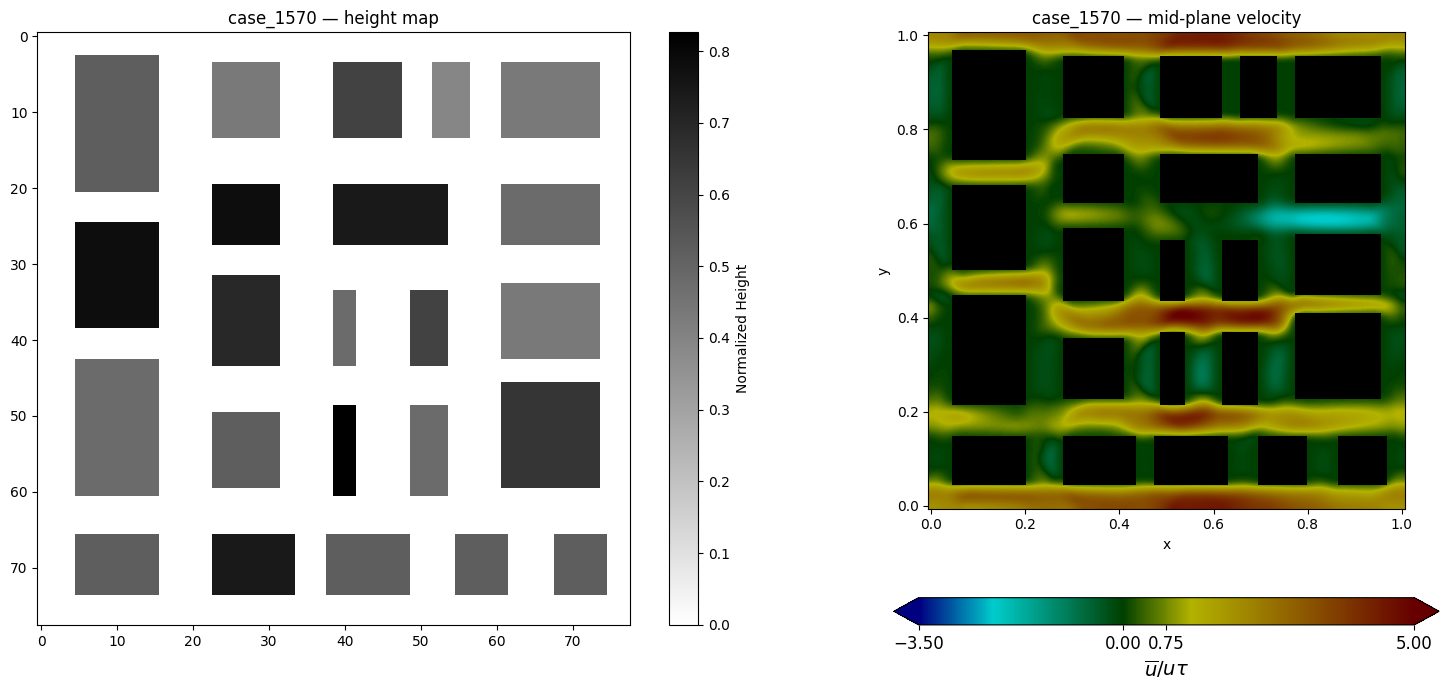

In [ ]:
CASE_N =random.randint(0, N_CASES - 1)
visualize_case(CASE_N, vmin=-3.5, vmax=5.0, save_path=os.path.expanduser('~/Urban-Flow-Transformer/docs/wp0_example_case.png'))

In [ ]:
# building-count distribution (uses the same extractor as the descriptors)
n_buildings = np.array([morphology.extract_buildings(X[i])[2] for i in range(len(X))])
print(f"mean {n_buildings.mean():.1f}   max {n_buildings.max()}   min {n_buildings.min()}")